# Modeling Goal

We want to create models that can predict multilabel classification 
['CD', 'HYP, 'MI', 'NORM', 'STTC]

# 🧠 ECG Modeling Pipeline (Low-Resolution PTB-XL)

---

## **1. Load Patient-Level Splits**

Load the saved `train`, `val`, and `test` patient ID CSVs.

**Why:**

* Ensures strict patient-level separation
* Prevents data leakage
* Guarantees reproducibility

---

## **2. Load and Prepare Metadata**

Load the main PTB-XL metadata CSV and:

* Convert `scp_codes`
* Generate `superclasses`
* Create multilabel vectors
* Attach split labels (train/val/test)

**Why:**

* This links waveforms to correct labels
* Ensures alignment between signals and targets

Output:

* Clean `df` with:

  * `filename_lr`
  * `superclasses`
  * `label_vector`
  * `split`

---

## **3. Define ECG Preprocessing Function (100 Hz)**

Create a reusable function that:

* Loads waveform from `filename_lr`
* Transposes to `(12, 1000)`
* Applies per-record z-score normalization

**Why:**

* Guarantees consistent signal format
* Prevents scaling bias
* Keeps pipeline modular

Output:

* Clean ECG tensor ready for modeling

---

## **4. Build Custom PyTorch Dataset Class**

Create `PTBXLDataset` that:

* Filters by split
* Loads ECG dynamically
* Applies preprocessing
* Returns `(signal, label)`

**Why:**

* Memory efficient
* Clean separation of concerns
* Allows easy augmentation later

---

## **5. Create DataLoaders**

Create:

* `train_loader`
* `val_loader`
* `test_loader`

With:

* Appropriate batch size
* Shuffle only for training
* `num_workers` optimized

**Why:**

* Enables mini-batch training
* Improves GPU utilization
* Handles batching automatically

---

## **6. Define Model Architecture**

Start with a strong baseline:

* 1D CNN or ResNet1D
* Input shape: `(batch, 12, 1000)`
* Output: 5 logits (multilabel)

**Why:**

* CNNs work extremely well on ECG
* Baseline model establishes performance floor

---

## **7. Define Loss Function and Optimizer**

Use:

* `BCEWithLogitsLoss()` (multilabel)
* Adam optimizer
* Optional: weight decay

**Why:**

* Proper loss for multilabel tasks
* Stable convergence

---

## **8. Training Loop**

For each epoch:

* Forward pass
* Compute loss
* Backpropagation
* Update weights

Track:

* Training loss
* Training AUROC (optional)

**Why:**

* Core optimization step

---

## **9. Validation Loop (Every Epoch)**

After each training epoch:

* Disable gradients
* Compute validation loss
* Compute validation AUROC

Use:

* Early stopping
* Save best model (based on validation AUROC)

**Why:**

* Prevents overfitting
* Selects best-performing model

---

## **10. Final Test Evaluation**

After training completes:

* Load best model
* Evaluate on test set once
* Compute:

  * Macro AUROC ⭐
  * Micro AUROC
  * Macro F1
  * Per-class AUROC

**Why:**

* Provides unbiased final performance estimate

---

## **11. Statistical Evaluation (Optional but Recommended)**

Since your project focuses on statistical rigor:

* Bootstrap confidence intervals
* Compare models statistically
* Report 95% CI for AUROC

---

# 🔥 Clean Research Flow Summary

```text
Splits → Metadata → Preprocessing → Dataset → Dataloader
→ Model → Train → Validate → Test → Statistical Evaluation
```

---


In [23]:
# Import Python Libraries
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import data specific library 
import wfdb 

# Import extra libraries 
from pathlib import Path
import sys

In [24]:
# ----------------------------
# Paths
# ----------------------------
project_root = Path("../")
splits_dir = project_root / "splits"
data_file = project_root / "data" / "ptbxl_database.csv" 
modules_dir = project_root / "modules"


# Make sure modules folder is in path for imports
sys.path.append(str(modules_dir))

# ----------------------------
# Load main dataframe
# ----------------------------
df = pd.read_csv(data_file)

# ----------------------------
# Load splits
# ----------------------------
train_patients = pd.read_csv(splits_dir / "train_patients.csv")["patient_id"].values
val_patients   = pd.read_csv(splits_dir / "val_patients.csv")["patient_id"].values
test_patients  = pd.read_csv(splits_dir / "test_patients.csv")["patient_id"].values

# ----------------------------
# Assign split column
# ----------------------------
df['split'] = "train"  # default
df.loc[df['patient_id'].isin(val_patients), 'split'] = "val"
df.loc[df['patient_id'].isin(test_patients), 'split'] = "test"

print(df.columns)

Index(['ecg_id', 'patient_id', 'age', 'sex', 'height', 'weight', 'nurse',
       'site', 'device', 'recording_date', 'report', 'scp_codes', 'heart_axis',
       'infarction_stadium1', 'infarction_stadium2', 'validated_by',
       'second_opinion', 'initial_autogenerated_report', 'validated_by_human',
       'baseline_drift', 'static_noise', 'burst_noise', 'electrodes_problems',
       'extra_beats', 'pacemaker', 'strat_fold', 'filename_lr', 'filename_hr',
       'split'],
      dtype='object')


In [25]:
def load_and_preprocess_ecg(
        record_path: Path, 
        normalize: bool = True, 
        expected_length: int = 1000
    ):
    """
    Load and preprocess ECG data from a given record path.

    Parameters:
        record_path : Path 
            The path to the ECG record.
        normalize : bool 
            Whether to normalize the ECG signal. Default is True.
        expected_length : int
            The expected length of the ECG signal. Default is 1000 samples (100 Hz = 1000 samples).

    Returns:
        ecg_signal : numpy.ndarray
            The preprocessed ECG signal.
        fs : int
            The sampling frequency of the ECG signal.
    """
    
    # Load the ECG record using wfdb
    signal, meta = wfdb.rdsamp(str(record_path))
    
    # wfdb returns shape (time, leads) → transpose
    signal = signal.T  # shape becomes (12, time)

    # Safety check
    if signal.shape[1] != expected_length:
        raise ValueError(
            f"Unexpected signal length {signal.shape[1]}, expected {expected_length}"
        )

    # Per-record z-score normalization
    if normalize:
        mean = signal.mean(axis=1, keepdims=True)
        std = signal.std(axis=1, keepdims=True) + 1e-8
        signal = (signal - mean) / std

    return signal.astype(np.float32)

In [26]:
# Test the pre-processing function on a sample record
example_filename = df.iloc[0]['filename_lr'] # Get the filename of the first record
record_path = project_root / "data" / example_filename

signal = load_and_preprocess_ecg(record_path)
print(f"Loaded ECG signal shape: {signal.shape}")
print("Mean per lead:", signal.mean(axis=1))
print("Std per lead:", signal.std(axis=1))

Loaded ECG signal shape: (12, 1000)
Mean per lead: [ 1.3950468e-07 -2.2202730e-08  8.2075594e-08 -3.9026141e-08
 -2.2935868e-07  7.8082083e-09  1.1979602e-08  1.6510487e-08
  5.9604646e-09  2.0027160e-08  1.7374754e-08  1.8477440e-08]
Std per lead: [1.0000008  0.99999976 0.9999995  1.0000001  0.99999917 1.
 1.         1.0000001  0.9999998  1.0000001  1.0000002  1.        ]


In [27]:
import matplotlib.pyplot as plt

def plot_ecg(signal, title="ECG Signal"):
    """
    Plot 12-lead ECG stacked vertically.
    
    Parameters
    ----------
    signal : np.ndarray
        Shape (12, 1000)
    """

    leads = [
        "I", "II", "III",
        "aVR", "aVL", "aVF",
        "V1", "V2", "V3",
        "V4", "V5", "V6"
    ]

    time = np.linspace(0, 10, signal.shape[1])  # 10 seconds at 100 Hz

    fig, axes = plt.subplots(12, 1, figsize=(12, 18), sharex=True)

    for i in range(12):
        axes[i].plot(time, signal[i])
        axes[i].set_ylabel(leads[i])
        axes[i].grid(True)

    axes[-1].set_xlabel("Time (seconds)")
    fig.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

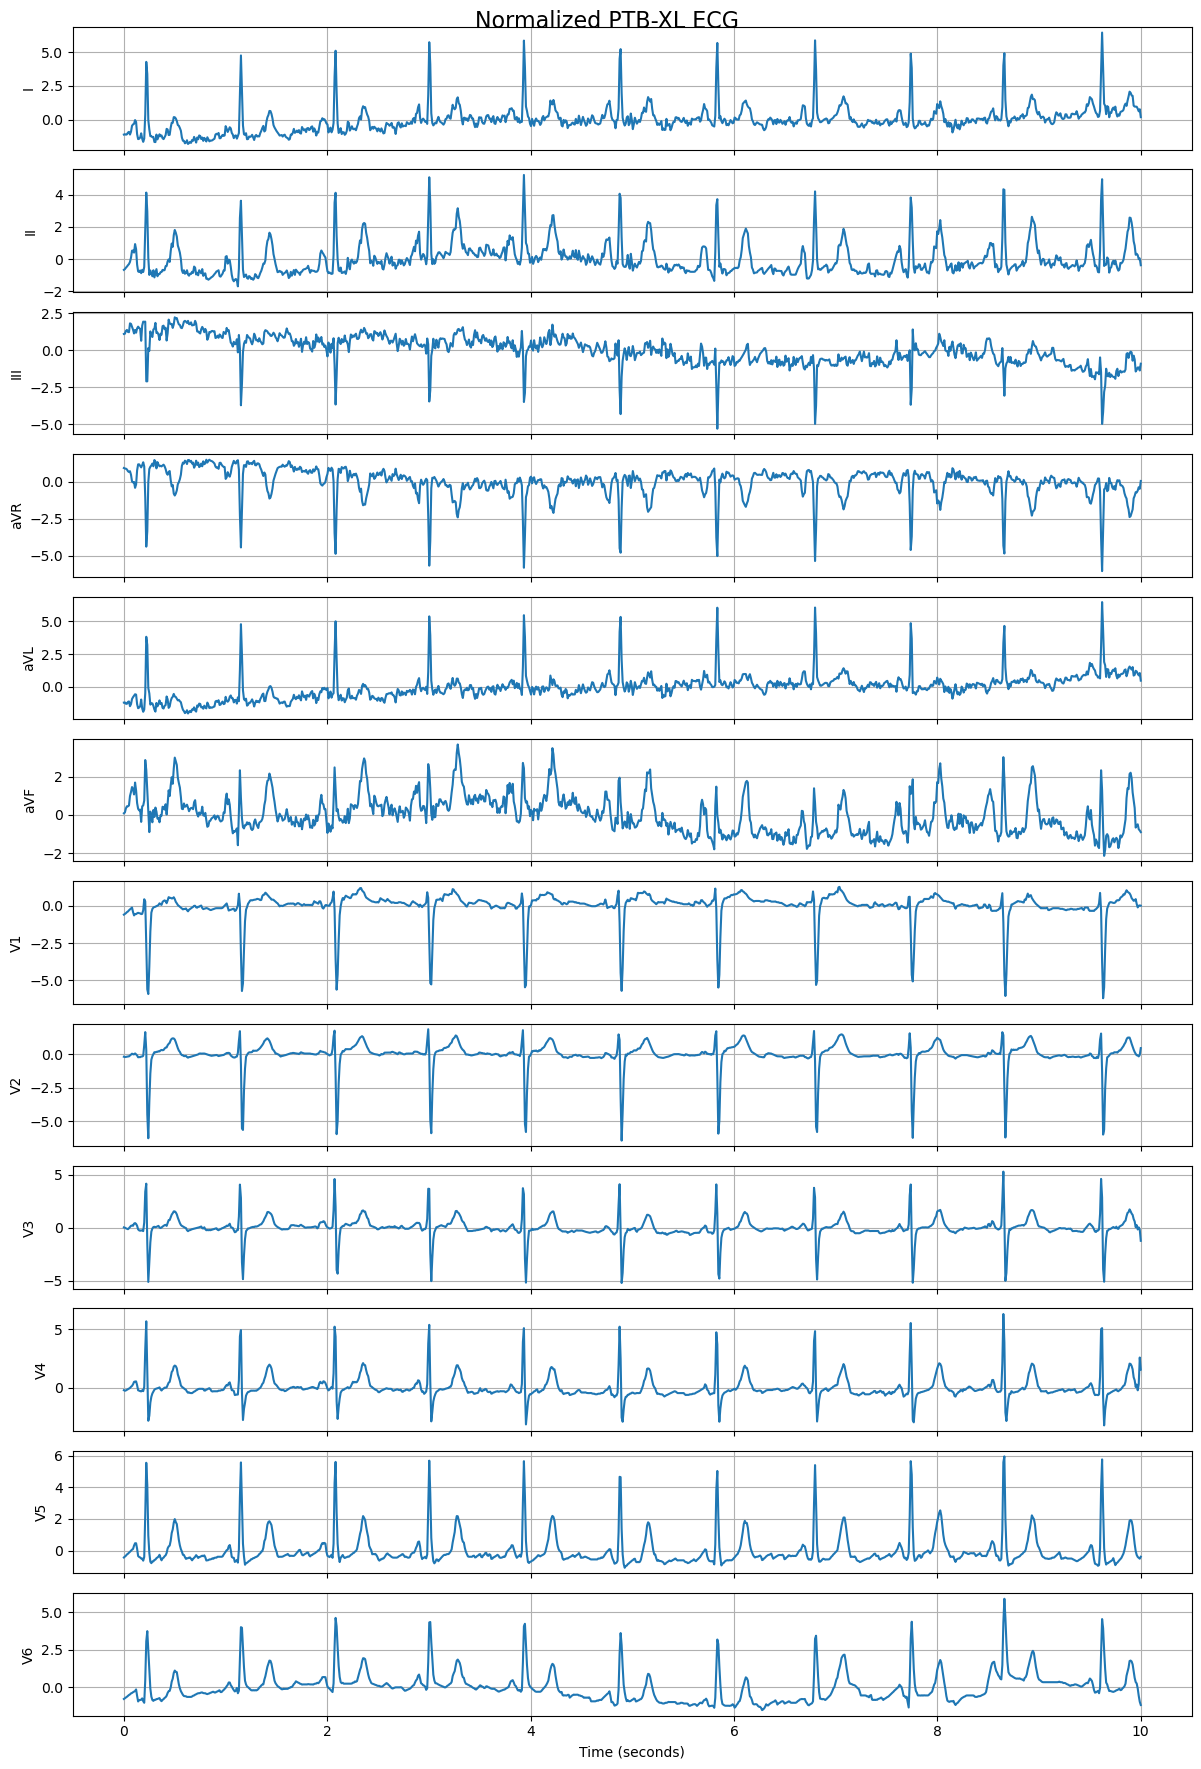

In [28]:
plot_ecg(signal, title="Normalized PTB-XL ECG")

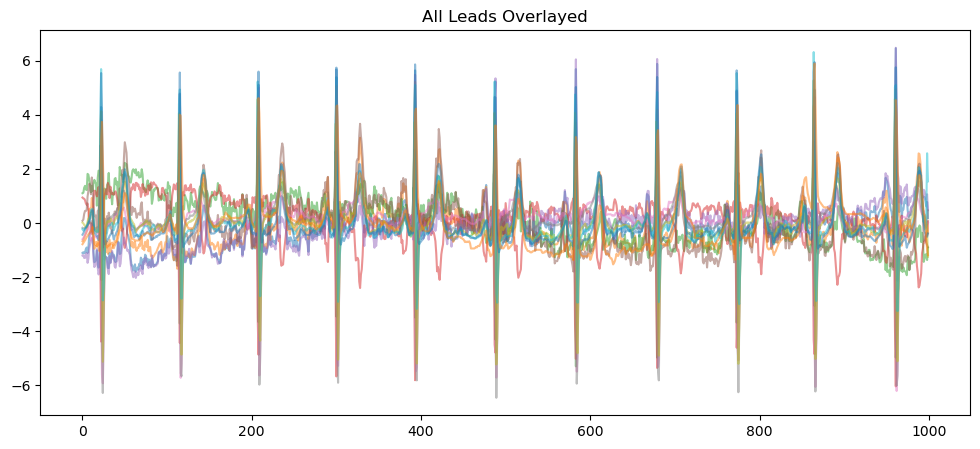

In [29]:
plt.figure(figsize=(12, 5))
for i in range(12):
    plt.plot(signal[i], alpha=0.5)
plt.title("All Leads Overlayed")
plt.show()

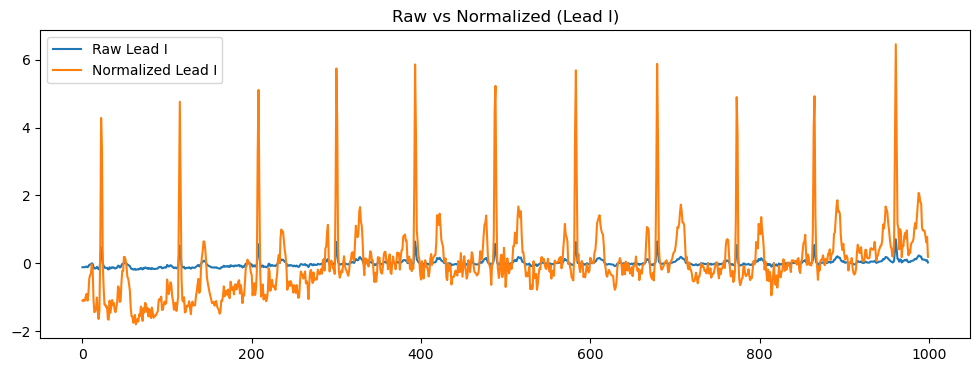

In [30]:
raw_signal, _ = wfdb.rdsamp(str(record_path))
raw_signal = raw_signal.T

normalized_signal = load_and_preprocess_ecg(record_path)

plt.figure(figsize=(12, 4))
plt.plot(raw_signal[0], label="Raw Lead I")
plt.plot(normalized_signal[0], label="Normalized Lead I")
plt.legend()
plt.title("Raw vs Normalized (Lead I)")
plt.show()

Frontal plane:  I, II, III, aVR, aVL, aVF
Horizontal plane:  V1–V6

| Condition         | Important Leads |
| ----------------- | --------------- |
| MI (inferior)     | II, III, aVF    |
| MI (anterior)     | V1–V4           |
| MI (lateral)      | I, aVL, V5, V6  |
| Conduction delays | V1, V6          |
| Hypertrophy       | V5, V6          |


Now that we know the pre-processing worked for ML modeling lets create our PTBXL Dataset class

In [31]:
import torch 
from torch.utils.data import Dataset

class PTBXLDataset(Dataset):
    def __init__(
            self, 
            df: pd.DataFrame,
            data_dir: Path,
            split: str, 
            normalize:bool = True
    ):
        """
        PTB-XL Dataset for multilabel classification.

        Parameters
        ----------
        df : pd.DataFrame
            Metadata dataframe containing filename_lr, label_vector, split.
        data_dir : Path
            Root directory containing PTB-XL waveform folders.
        split : str
            One of ["train", "val", "test"].
        normalize : bool
            Whether to apply per-record z-score normalization.
        """

        self.df = df[df['split'] == split].reset_index(drop=True) # Filter dataframe for the specified split
        self.data_dir = data_dir # Root directory for ECG files
        self.normalize = normalize # Whether to normalize signals
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        # Get the record metadata for the given index
        record_info = self.df.iloc[idx]
        filename = record_info['filename_lr'] # e.g., "ptbxl_01/00001_01"

        # Build full path to record 
        record_path = self.data_dir / filename

        # Load and preprocess the ECG signal
        signal = load_and_preprocess_ecg(
            record_path, 
            normalize=self.normalize
        )

        # Convert label vector to tensor
        label = torch.tensor(record_info["label_vector"], dtype=torch.float32)

        # Convert signal to tensor
        signal = torch.tensor(signal, dtype=torch.float32)

        return signal, label

In [32]:
import ast 
from organization import extract_superclasses 

# The 'scp_codes' column contains string representations of dictionaries. We need to convert them to actual dictionaries for analysis.
df["scp_codes"] = df["scp_codes"].apply(ast.literal_eval)

# Load the mapping file for SCP codes to their descriptions
scp_file = "../data/scp_statements.csv"
scp_statements = pd.read_csv(scp_file)
print(scp_statements.columns) # Check the columns in the scp_statements dataframe

# Fix the first column name which should be our scp_code
scp_statements = scp_statements.rename(columns={scp_statements.columns[0]: "scp_code"})
print(scp_statements.columns) # Check the columns again to confirm the rename

# Keep only diagnostic classes/codes
scp_diag = scp_statements[scp_statements["diagnostic"] == 1]

# Create mapping from code to superclass (scp_code to diagnostic_class)
code_to_superclass = dict(
    zip(scp_diag["scp_code"], scp_diag["diagnostic_class"])
)
print("Example mapping:")
print(list(code_to_superclass.items())[:10])

# Apply function to the dataframe
df["superclasses"] = df["scp_codes"].apply(lambda x: extract_superclasses(x, code_to_superclass))
# Flatten all superclasses into one list and get unique values
unique_superclasses = set(cls for sublist in df["superclasses"] for cls in sublist)

print("Unique superclasses in dataset:")
print(unique_superclasses)
print(f"Total unique superclasses: {len(unique_superclasses)}")

Index(['Unnamed: 0', 'description', 'diagnostic', 'form', 'rhythm',
       'diagnostic_class', 'diagnostic_subclass', 'Statement Category',
       'SCP-ECG Statement Description', 'AHA code', 'aECG REFID', 'CDISC Code',
       'DICOM Code'],
      dtype='object')
Index(['scp_code', 'description', 'diagnostic', 'form', 'rhythm',
       'diagnostic_class', 'diagnostic_subclass', 'Statement Category',
       'SCP-ECG Statement Description', 'AHA code', 'aECG REFID', 'CDISC Code',
       'DICOM Code'],
      dtype='object')
Example mapping:
[('NDT', 'STTC'), ('NST_', 'STTC'), ('DIG', 'STTC'), ('LNGQT', 'STTC'), ('NORM', 'NORM'), ('IMI', 'MI'), ('ASMI', 'MI'), ('LVH', 'HYP'), ('LAFB', 'CD'), ('ISC_', 'STTC')]
Unique superclasses in dataset:
{'STTC', 'MI', 'NORM', 'CD', 'HYP'}
Total unique superclasses: 5


In [34]:
CLASS_NAMES = ['NORM', 'MI', 'STTC', 'CD', 'HYP']

def build_label_vector(superclasses):
    """
    Convert list of superclass strings
    into fixed-order binary multilabel vector.
    """
    return np.array(
        [1 if cls in superclasses else 0 for cls in CLASS_NAMES],
        dtype=np.float32
    )

df["label_vector"] = df["superclasses"].apply(build_label_vector)

print("Example superclasses:", df.iloc[0]["superclasses"])
print("Example label vector:", df.iloc[0]["label_vector"])

Example superclasses: ['NORM']
Example label vector: [1. 0. 0. 0. 0.]


In [36]:
multi_label_rows = df[df["label_vector"].apply(lambda x: x.sum() > 1)]

print("Number of multilabel samples:", len(multi_label_rows))
multi_label_rows.head()

Number of multilabel samples: 5144


,ecg_id,patient_id,age,sex,height,weight,nurse,site,device,recording_date,...,burst_noise,electrodes_problems,extra_beats,pacemaker,strat_fold,filename_lr,filename_hr,split,superclasses,label_vector
38,39,13619.0,56.0,0,NaN,NaN,2.0,0.0,CS-12 E,1985-02-16 12:54:01,...,NaN,NaN,NaN,NaN,9,records100/00000/00039_lr,records500/00000/00039_hr,test,"[STTC, MI]","[0.0, 1.0, 1.0, 0.0, 0.0]"
44,45,18794.0,51.0,0,NaN,106.0,2.0,0.0,CS-12 E,1985-03-21 15:21:20,...,NaN,NaN,NaN,NaN,1,records100/00000/00045_lr,records500/00000/00045_hr,train,"[CD, HYP]","[0.0, 0.0, 0.0, 1.0, 1.0]"
49,50,16961.0,59.0,1,NaN,64.0,2.0,0.0,CS-12 E,1985-05-09 12:01:24,...,NaN,NaN,NaN,NaN,7,records100/00000/00050_lr,records500/00000/00050_hr,train,"[CD, MI]","[0.0, 1.0, 0.0, 1.0, 0.0]"
76,77,8555.0,43.0,0,NaN,63.0,0.0,0.0,CS-12 E,1985-09-27 09:55:22,...,NaN,NaN,NaN,NaN,6,records100/00000/00077_lr,records500/00000/00077_hr,train,"[CD, MI]","[0.0, 1.0, 0.0, 1.0, 0.0]"
86,87,17293.0,19.0,0,NaN,69.0,2.0,0.0,CS-12 E,1985-11-15 10:45:32,...,NaN,NaN,NaN,NaN,7,records100/00000/00087_lr,records500/00000/00087_hr,val,"[CD, STTC]","[0.0, 0.0, 1.0, 1.0, 0.0]"


In [35]:
label_matrix = np.stack(df["label_vector"].values)

print("Class counts:")
for i, cls in enumerate(CLASS_NAMES):
    print(cls, int(label_matrix[:, i].sum()))

Class counts:
NORM 9514
MI 5469
STTC 5235
CD 4898
HYP 2649


In [37]:
train_dataset = PTBXLDataset(df, project_root / "data", split="train")
val_dataset   = PTBXLDataset(df, project_root / "data", split="val")
test_dataset  = PTBXLDataset(df, project_root / "data", split="test")

print("Train size:", len(train_dataset))
signal, label = train_dataset[0]

print("Signal shape:", signal.shape)
print("Label shape:", label.shape)

Train size: 15275
Signal shape: torch.Size([12, 1000])
Label shape: torch.Size([5])
